# ML-Klassifikations-Benchmark (Iris-Datensatz)

Dieses Notebook führt den Benchmark von ML-Klassifikationsmodellen auf dem Iris-Datensatz durch.
Es werden die Klassen aus dem Ordner `src/` verwendet.

### Verwendete GoF Design Patterns

| Pattern | Wo | Beschreibung                                                                                                                                                 |
|---------|----|--------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Strategy** | `interfaces.py`, `strategies.py`, `trainer.py` | `ClassifierStrategy` (ABC) definiert `fit()` und `predict()`. <br/>8 konkrete Strategien implementieren das Interface. Der `Trainer` kennt nur das Interface. |
| **Factory** | `factory.py` | `ClassifierFactory.make_classifier()` erzeugt Strategien über String-Keys. <br/>Der Client muss keine konkreten Klassen kennen.                              |
| **Decorator** | `interfaces.py`, `strategies.py` | `@log_method` loggt automatisch alle `fit()`- und `predict()`-Aufrufe, ohne den Code zu verändern.                                                           |
| **Adapter** | `adapter.py`, `main.py` | `SklearnAdapter` adaptiert beliebige sklearn-Modelle an `ClassifierStrategy` ohne eine neue Strategy-Klasse zu benötigen.                                    |

---
## 1. Setup & Imports

Projektverzeichnis zum Python-Pfad hinzufügen und alle benötigten Klassen importieren

In [1]:
import sys
import os

# Projektverzeichnis zum Pfad hinzufügen (eine Ebene über notebooks/)
projekt_pfad = os.path.abspath(os.path.join(os.getcwd(), '..'))
if projekt_pfad not in sys.path:
    sys.path.insert(0, projekt_pfad)

print(f"Projekt-Pfad: {projekt_pfad}")

Projekt-Pfad: C:\Code\AUGSBURG_10237747_Python_Simon


In [2]:
import logging
import matplotlib.pyplot as plt
from IPython.display import display, Image

from src.trainer import Trainer
from src.factory import ClassifierFactory
from src.adapter import SklearnAdapter

# Logging konfigurieren
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s", stream=sys.stdout)

# Matplotlib-Grafiken inline anzeigen
%matplotlib inline

print("Alle Imports erfolgreich!")

Alle Imports erfolgreich!


---
## 2. Trainer erstellen und Daten vorbereiten

Der `Trainer` ist der **Kontext** im Strategy Pattern. Er lädt den Iris-Datensatz und splittet ihn in 15 Test- und 135 Trainingsdaten.

In [3]:
# Kontext erstellen
trainer = Trainer()

# Daten laden und splitten
trainer.prepare_data()

# Ausgabe zur visualisierung
print(f"Trainings-Datensatz:  {len(trainer.train_data)} Samples")
print(f"Test-Datensatz:       {len(trainer.test_data)} Samples")
print(f"Features:             {trainer.features}")
print(f"Target:               {trainer.target}")

Trainings-Datensatz:  135 Samples
Test-Datensatz:       15 Samples
Features:             ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target:               species


### Trainingsdaten Preview

In [4]:
# 10 Zeilen des Trainingsdatensatzes
trainer.train_data.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
104,6.5,3.0,5.8,2.2,virginica
36,5.5,3.5,1.3,0.2,setosa
13,4.3,3.0,1.1,0.1,setosa
63,6.1,2.9,4.7,1.4,versicolor
45,4.8,3.0,1.4,0.3,setosa
28,5.2,3.4,1.4,0.2,setosa
133,6.3,2.8,5.1,1.5,virginica
24,4.8,3.4,1.9,0.2,setosa
127,6.1,3.0,4.9,1.8,virginica
46,5.1,3.8,1.6,0.2,setosa


---
## 3. Benchmark – Alle 8 Strategien

Für jede der 8 Strategien wird:
1. Die Factory (`ClassifierFactory.make_classifier`) erzeugt das Strategie-Objekt über den Key → **Factory Pattern**
2. Der Trainer (`run_single`) führt Training, Vorhersage und Auswertung durch → **Strategy Pattern**
3. Die `@log_method` loggt automatisch die Aufrufe von `fit()` und `predict()` → **Decorator Pattern**
4. Eine Confusion-Matrix-Heatmap wird erstellt und gespeichert → `Metric.plot_confusion_matrix`

[INFO] DecisionTreeStrategy.fit() – 135 Samples
[INFO] DecisionTreeStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_tree.png
tree abgeschlossen. Error Rate: 0.0667


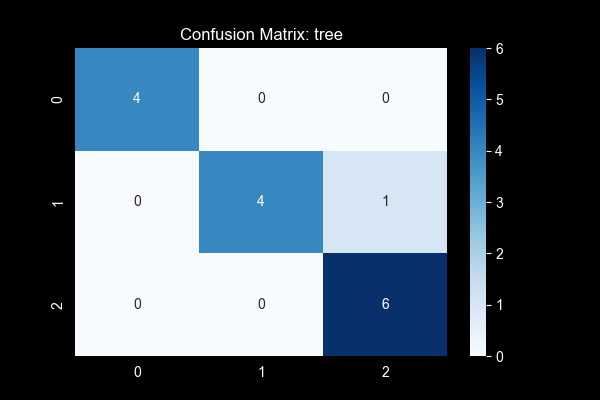

[INFO] RandomForestStrategy.fit() – 135 Samples
[INFO] RandomForestStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_rf.png
rf abgeschlossen. Error Rate: 0.0000


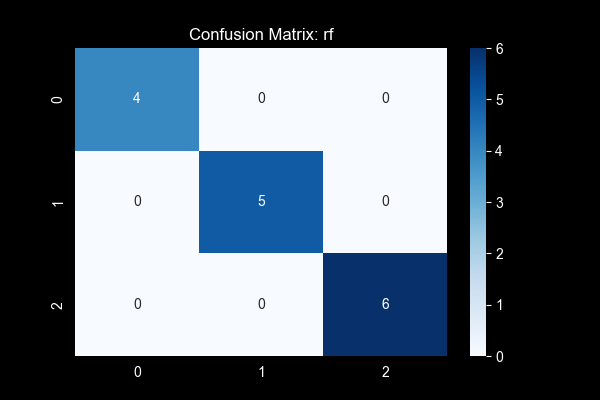

[INFO] LDAStrategy.fit() – 135 Samples
[INFO] LDAStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_lda.png
lda abgeschlossen. Error Rate: 0.0000


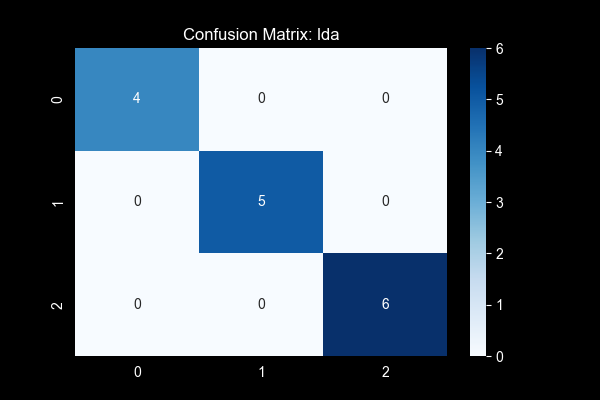

[INFO] SVCRbfStrategy.fit() – 135 Samples
[INFO] SVCRbfStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_svm_rbf.png
svm_rbf abgeschlossen. Error Rate: 0.0667


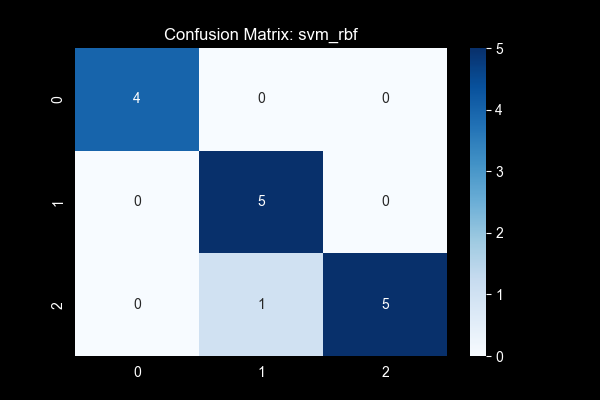

[INFO] SVCLinearStrategy.fit() – 135 Samples
[INFO] SVCLinearStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_svm_linear.png
svm_linear abgeschlossen. Error Rate: 0.0667


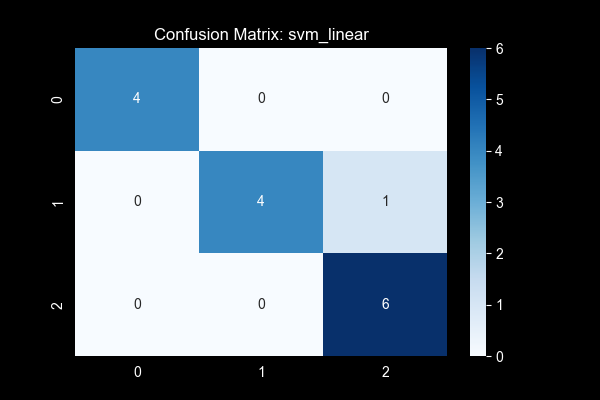

[INFO] SVCPoly3Strategy.fit() – 135 Samples
[INFO] SVCPoly3Strategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_svm_poly3.png
svm_poly3 abgeschlossen. Error Rate: 0.0667


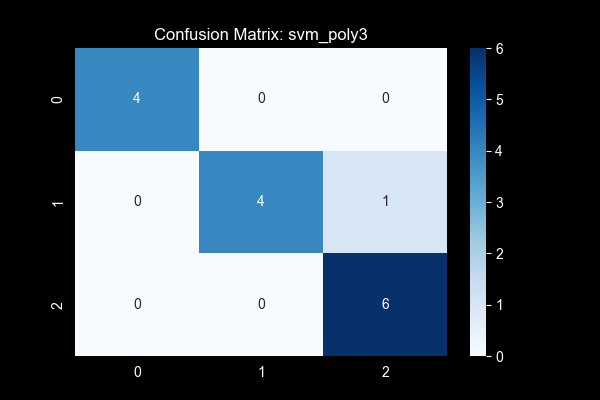

[INFO] LinearSVCStrategy.fit() – 135 Samples
[INFO] LinearSVCStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_linear_svc.png
linear_svc abgeschlossen. Error Rate: 0.0000


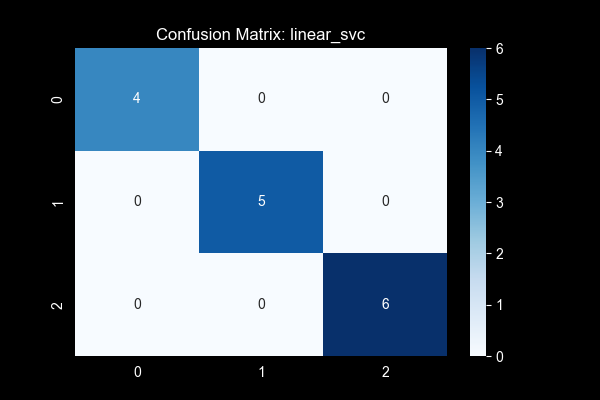

[INFO] XGBoostStrategy.fit() – 135 Samples
[INFO] XGBoostStrategy.predict() – 15 Samples
Grafik gespeichert: results/heatmap_xgboost.png
xgboost abgeschlossen. Error Rate: 0.0667


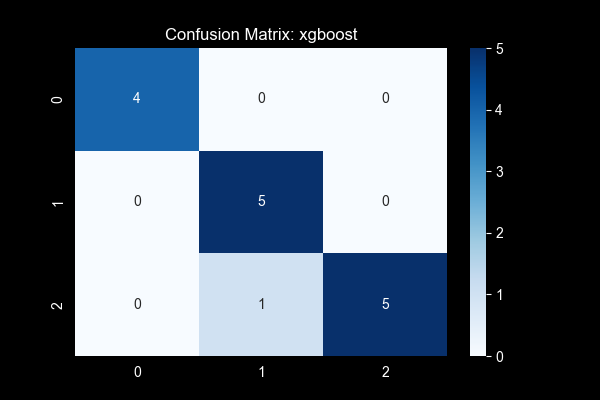

In [9]:
# Liste der Strategien
strategy_names = [
    "tree",
    "rf",
    "lda",
    "svm_rbf",
    "svm_linear",
    "svm_poly3",
    "linear_svc",
    "xgboost"
]

# Heatmap aktiviert
visualisierung = True

# Benchmark
try:
    for name in strategy_names:
        # Client erstellt die Strategie via Factory
        strategy = ClassifierFactory.make_classifier(name, random_state=123)
        # Client injiziert sie in den Kontext
        trainer.run_single(strategy, name, visualisierung)
        # Gespeicherte Heatmap manuell anzeigen
        display(Image(filename=f"results/heatmap_{name}.png"))
except Exception as e:
    print(f"Fehler: {e}")

---
## 4. Adapter Pattern

Der `SklearnAdapter` passt ein beliebiges sklearn-Modell an das `ClassifierStrategy`-Interface an, ohne eine neue Strategy-Klasse zu schreiben. Hier wird ein `KNeighborsClassifier` über den Adapter eingebunden


Adapter-Pattern: KNeighborsClassifier
[INFO] SklearnAdapter.fit() – 135 Samples
[INFO] SklearnAdapter.predict() – 15 Samples
Grafik gespeichert: results/heatmap_adapter_knn.png
adapter_knn abgeschlossen. Error Rate: 0.0667


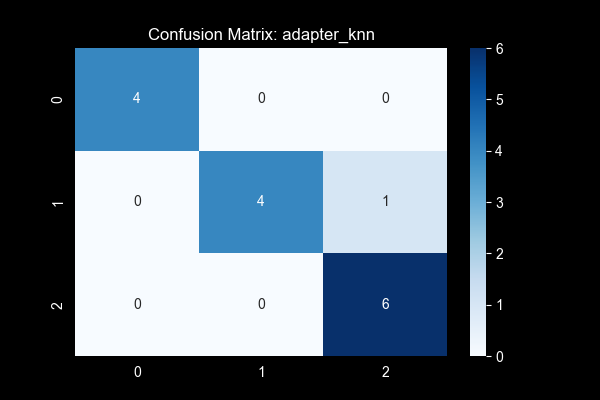

In [10]:
# Adapter-Pattern adaptiert ein beliebiges sklearn-Modell
print("\nAdapter-Pattern: KNeighborsClassifier")
from sklearn.neighbors import KNeighborsClassifier
knn_adapter = SklearnAdapter(KNeighborsClassifier(n_neighbors=3))
trainer.run_single(knn_adapter, "adapter_knn", visualisierung)
# Gespeicherte Heatmap anzeigen
display(Image(filename="results/heatmap_adapter_knn.png"))

---
## 5. Ergebnis-Zusammenfassung

Der Trainer gibt ein Ranking aller Modelle sortiert nach Error Rate aus – identisch zur Ausgabe von `main.py`.

In [11]:
# Zusammenfassung (wie in main.py)
trainer.print_summary()


          Zusammenfassung
Rang  Modell          Error Rate  Accuracy
1     rf              0.0000      100.00%
2     lda             0.0000      100.00%
3     linear_svc      0.0000      100.00%
4     tree            0.0667      93.33%
5     svm_rbf         0.0667      93.33%
6     svm_linear      0.0667      93.33%
7     svm_poly3       0.0667      93.33%
8     xgboost         0.0667      93.33%
9     adapter_knn     0.0667      93.33%
